In [1]:
import pandas as pd 

In [2]:
# load eda data
df=pd.read_csv('C:/Users/swapn/Loan-Approval-Prediction/data/processed/eda.csv')

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Handling Missing Values

In [4]:
df.isnull()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
Loan_Amount          22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
# fill numerical column use mean and meadian , but medan is the best 
df['Loan_Amount']=df['Loan_Amount'].fillna(df['Loan_Amount'].median())

In [7]:
df['Loan_Amount']

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: Loan_Amount, Length: 614, dtype: float64

In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
Loan_Amount           0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [10]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
Loan_Amount           0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
# advanced methods ffill and bfill
df=df.bfill()

In [12]:
df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
Loan_Amount          0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Encode categorical data 

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   Loan_Amount        614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [14]:
# label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder() 
df['Gender']=le.fit_transform(df['Gender'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   Loan_Amount        614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


In [16]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,1,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,1,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,1,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,1,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,1,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,1,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [17]:
# drop use less feature 
df=df.drop('Loan_ID',axis=1)

In [18]:
df=df.drop('Dependents',axis=1)

In [19]:
df=df.drop('Property_Area',axis=1)

In [20]:
df

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status
0,1,No,Graduate,No,5849,0.0,128.0,360.0,1.0,Y
1,1,Yes,Graduate,No,4583,1508.0,128.0,360.0,1.0,N
2,1,Yes,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Y
3,1,Yes,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Y
4,1,No,Graduate,No,6000,0.0,141.0,360.0,1.0,Y
...,...,...,...,...,...,...,...,...,...,...
609,0,No,Graduate,No,2900,0.0,71.0,360.0,1.0,Y
610,1,Yes,Graduate,No,4106,0.0,40.0,180.0,1.0,Y
611,1,Yes,Graduate,No,8072,240.0,253.0,360.0,1.0,Y
612,1,Yes,Graduate,No,7583,0.0,187.0,360.0,1.0,Y


In [21]:
df=pd.get_dummies(df,drop_first=True).astype(int)

In [22]:
df

,Gender,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Loan_Status_Y
0,1,5849,0,128,360,1,0,0,0,1
1,1,4583,1508,128,360,1,1,0,0,0
2,1,3000,0,66,360,1,1,0,1,1
3,1,2583,2358,120,360,1,1,1,0,1
4,1,6000,0,141,360,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0,71,360,1,0,0,0,1
610,1,4106,0,40,180,1,1,0,0,1
611,1,8072,240,253,360,1,1,0,0,1
612,1,7583,0,187,360,1,1,0,0,1


In [23]:
# rename column 
df.rename(columns={
    'Married_Yes':'Married',
    'Self_Employed_Yes':'Self_Employed',
    'Loan_Status_Y':'Loan_Status'    
},inplace=True)

In [24]:
df

,Gender,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Married,Education_Not Graduate,Self_Employed,Loan_Status
0,1,5849,0,128,360,1,0,0,0,1
1,1,4583,1508,128,360,1,1,0,0,0
2,1,3000,0,66,360,1,1,0,1,1
3,1,2583,2358,120,360,1,1,1,0,1
4,1,6000,0,141,360,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0,71,360,1,0,0,0,1
610,1,4106,0,40,180,1,1,0,0,1
611,1,8072,240,253,360,1,1,0,0,1
612,1,7583,0,187,360,1,1,0,0,1


# Scaling

before scaling data split 

In [25]:
# input X and output y
X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

data can be split into 80% training data and 20% test data

In [26]:
# train test split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

apply StandardScaler for scaling

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler() 
X_train_scaled=scaler.fit_transform(X_train)     # fit only train data not the test data
X_test_scaled=scaler.transform(X_test)

In [28]:
df

,Gender,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Married,Education_Not Graduate,Self_Employed,Loan_Status
0,1,5849,0,128,360,1,0,0,0,1
1,1,4583,1508,128,360,1,1,0,0,0
2,1,3000,0,66,360,1,1,0,1,1
3,1,2583,2358,120,360,1,1,1,0,1
4,1,6000,0,141,360,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0,71,360,1,0,0,0,1
610,1,4106,0,40,180,1,1,0,0,1
611,1,8072,240,253,360,1,1,0,0,1
612,1,7583,0,187,360,1,1,0,0,1


# Remove duplicates

In [29]:
df=df.drop_duplicates().reset_index(drop=True)

In [30]:
df

,Gender,ApplicantIncome,CoapplicantIncome,Loan_Amount,Loan_Amount_Term,Credit_History,Married,Education_Not Graduate,Self_Employed,Loan_Status
0,1,5849,0,128,360,1,0,0,0,1
1,1,4583,1508,128,360,1,1,0,0,0
2,1,3000,0,66,360,1,1,0,1,1
3,1,2583,2358,120,360,1,1,1,0,1
4,1,6000,0,141,360,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0,71,360,1,0,0,0,1
610,1,4106,0,40,180,1,1,0,0,1
611,1,8072,240,253,360,1,1,0,0,1
612,1,7583,0,187,360,1,1,0,0,1


# Check data

how many rows and columns

In [31]:
df.shape

(614, 10)

cheack missing values

In [32]:
df.isnull().sum()

Gender                    0
ApplicantIncome           0
CoapplicantIncome         0
Loan_Amount               0
Loan_Amount_Term          0
Credit_History            0
Married                   0
Education_Not Graduate    0
Self_Employed             0
Loan_Status               0
dtype: int64

cheak all data in number

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  614 non-null    int64
 1   ApplicantIncome         614 non-null    int64
 2   CoapplicantIncome       614 non-null    int64
 3   Loan_Amount             614 non-null    int64
 4   Loan_Amount_Term        614 non-null    int64
 5   Credit_History          614 non-null    int64
 6   Married                 614 non-null    int64
 7   Education_Not Graduate  614 non-null    int64
 8   Self_Employed           614 non-null    int64
 9   Loan_Status             614 non-null    int64
dtypes: int64(10)
memory usage: 48.1 KB


Correlation heatmap

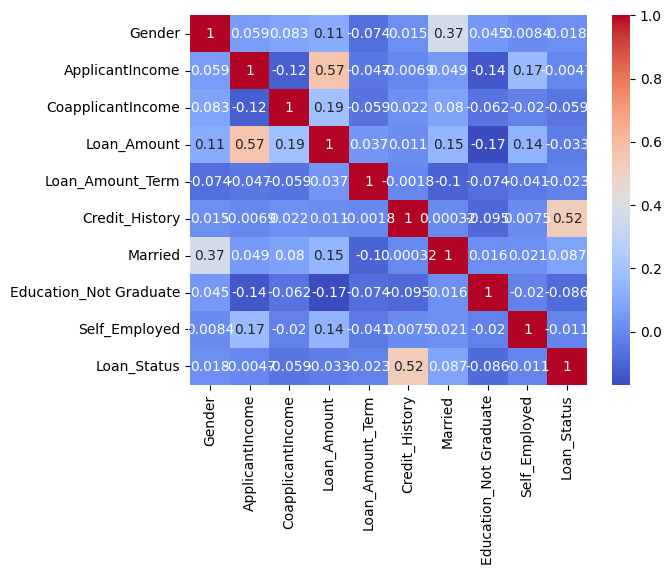

In [34]:
import matplotlib.pyplot as plt 
import seaborn as sns  
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)
plt.show()

# save clean data

In [35]:
df.to_csv('C:/Users/swapn/Loan-Approval-Prediction/data/processed/clean_data.csv')